In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.visualization import ZScaleInterval
from matplotlib.patches import Ellipse


In [5]:
isSavingplot = True

FITS_PATH = "../../data/raw/fits/jw02107-o039_t018_miri_f770w_i2d.fits"

CATALOGUE = "../../data/processed/metadata/mergedCatalogue.txt"

BAD_BUBBLE_PATH = "../../data/processed/metadata/badBubbles.txt"

OUTPUT_DIR = "../../outputs/figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [6]:
hdul = fits.open(FITS_PATH)

# Usually JWST science image is in extension 1
image = hdul[1].data
wcs = WCS(hdul[1].header)

print("Image shape:", image.shape)

Image shape: (1177, 2380)


Set DATE-AVG to '2022-07-17T12:01:53.586' from MJD-AVG.
Set DATE-END to '2022-07-17T12:54:46.016' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -37.754891 from OBSGEO-[XYZ].
Set OBSGEO-H to 1738895745.202 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [7]:
# catalogues = []

# # creating a combined catalogue
# for source_name, path in CATALOGUE_FILES.items():
#     df = pd.read_csv(path)
    
#     df["catalogue_source"] = source_name
#     df["original_id"] = df["ID"]
    
#     catalogues.append(df)

# catalogue = pd.concat(catalogues, ignore_index=True)

# # Creating a globally unique ID
# catalogue.insert(0, "global_id", np.arange(1, len(catalogue) + 1))

# print("Total bubbles:", len(catalogue))
# catalogue[["global_id", "catalogue_source", "original_id"]].head()


In [8]:
catalogue = pd.read_csv(CATALOGUE)

catalogue.head()


,GLOBAL_ID,ID,RA_DMS,DEC_DMS,SEMI_MAJ_PC,SEMI_MIN_PC,AVG_RAD_PC,PA_DEG,ARM,DIST_ARM_PC,GAL_RAD_KPC,CATALOGUE
0,1,1,24d08m55.9s,15d48m7.9s,86,86,86,0,3,145,5.22,A
1,2,2,24d08m56.7s,15d48m2.9s,24,24,24,0,3,127,5.05,A
2,3,3,24d08m57.0s,15d48m9.0s,42,42,42,0,3,138,5.21,A
3,4,4,24d08m58.0s,15d47m44.9s,25,25,25,0,3,101,4.54,A
4,5,5,24d08m58.2s,15d48m2.6s,24,24,24,0,3,114,4.98,A


In [9]:
bad_bubble_id = pd.read_csv(BAD_BUBBLE_PATH)

bad_bubble_id["GLOBAL_ID"] = bad_bubble_id["GLOBAL_ID"].astype(int)

print("Total bad bubbles:", len(bad_bubble_id))
bad_bubble_id.head()

Total bad bubbles: 766


,GLOBAL_ID
0,26
1,110
2,255
3,282
4,2345


In [10]:
catalogue["GLOBAL_ID"] = catalogue["GLOBAL_ID"].astype(int)
# catalogue["catalogue_source"] = catalogue["catalogue_source"].astype(str).str.strip()

bad_bubbles = catalogue.merge(
    bad_bubble_id,
    left_on=["GLOBAL_ID"],
    right_on=["GLOBAL_ID"],
    how="inner" # discard non-matching bubbles
)

# print("Total bad bubbles in catalogues:", len(bad_bubbles))

In [11]:
def clean_ra_dec_string(value):
    """
    Keeps RA/Dec strings consistent for Astropy.
    Example expected format:
    RA_DMS  = 24d11m9.6s
    DEC_DMS = 15d46m20.7s
    """
    return str(value).strip()


x_pix = []
y_pix = []

for _, row in bad_bubbles.iterrows():
    # ra_str = clean_ra_dec_string(row["RA_DMS"])
    # dec_str = clean_ra_dec_string(row["DEC_DMS"])
    ra_str = str(row["RA_DMS"]).strip()
    dec_str = str(row["DEC_DMS"]).strip()
    
    coord = SkyCoord(ra_str, dec_str, unit=(u.deg, u.deg), frame="icrs")
    x, y = wcs.world_to_pixel(coord)
    
    x_pix.append(x)
    y_pix.append(y)

bad_bubbles["x_pix"] = x_pix
bad_bubbles["y_pix"] = y_pix



In [12]:
cdelt1 = abs(hdul[1].header.get("CDELT1", hdul[0].header.get("CDELT1")))
cdelt2 = abs(hdul[1].header.get("CDELT2", hdul[0].header.get("CDELT2")))

pixel_scale_deg = np.mean([cdelt1, cdelt2])
pixel_scale_arcsec = pixel_scale_deg * 3600

distance_pc = 9.77e6
pc_per_arcsec = distance_pc / 206265
pc_per_pixel = pixel_scale_arcsec * pc_per_arcsec

print("pc_per_pixel:", pc_per_pixel)

bad_bubbles["semi_major_pix"] = bad_bubbles["SEMI_MAJ_PC"] / pc_per_pixel
bad_bubbles["semi_minor_pix"] = bad_bubbles["SEMI_MIN_PC"] / pc_per_pixel

pc_per_pixel: 5.254140159227344


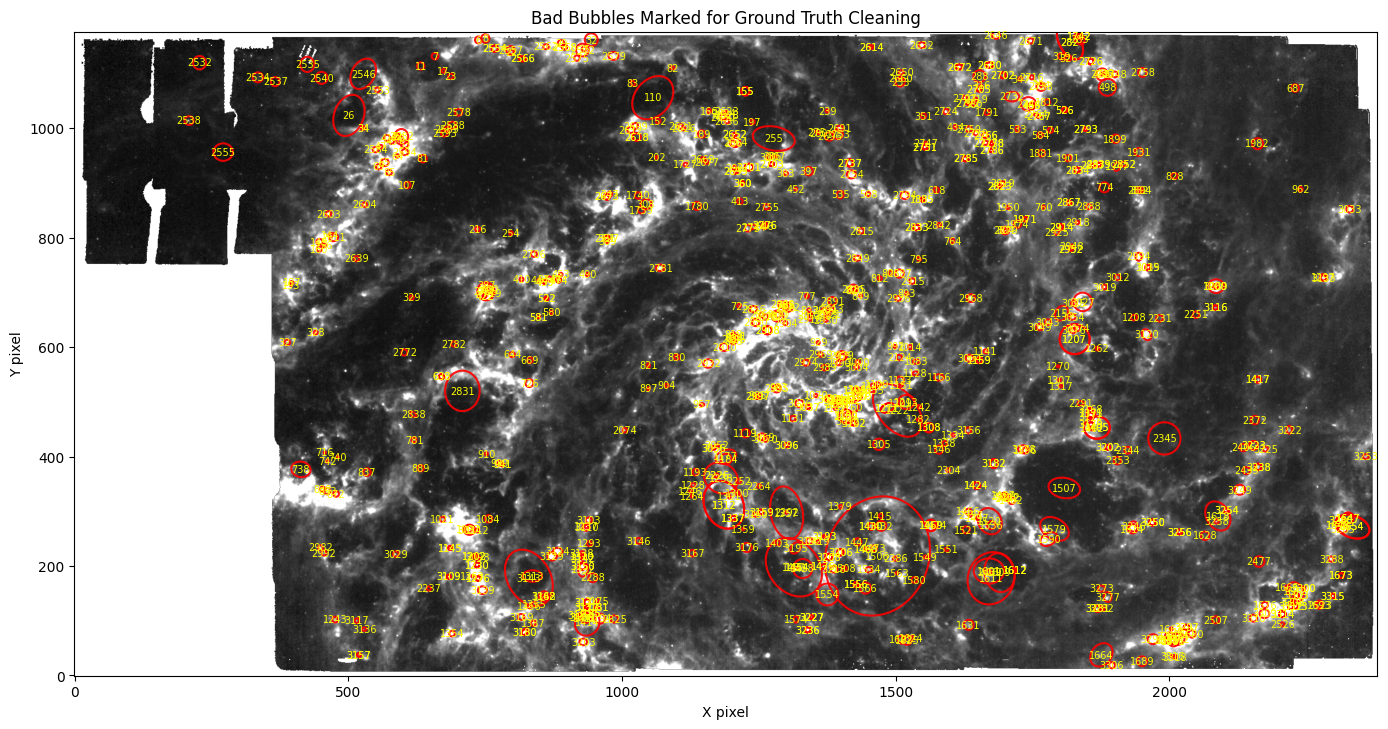

Saved plot to: ../../outputs/figures/bad_bubbles_overlay.png


In [15]:
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(image)

fig, ax = plt.subplots(figsize=(14, 8))

ax.imshow(image, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)

for _, row in bad_bubbles.iterrows():
    ellipse = Ellipse(
        xy=(row["x_pix"], row["y_pix"]),
        width=2 * row["semi_major_pix"],
        height=2 * row["semi_minor_pix"],
        angle=row["PA_DEG"],
        edgecolor="red",
        facecolor="none",
        linewidth=1.5,
        alpha=0.9,
    )
    ax.add_patch(ellipse)

    ax.text(
        row["x_pix"],
        row["y_pix"],
        f"{row['GLOBAL_ID']}",
        color="yellow",
        fontsize=7,
        ha="center",
        va="center",
    )

ax.set_title("Bad Bubbles Marked for Ground Truth Cleaning")
ax.set_xlabel("X pixel")
ax.set_ylabel("Y pixel")

plt.tight_layout()



if isSavingplot:
    output_path = os.path.join(OUTPUT_DIR, "bad_bubbles_overlay.png")
    plt.savefig(output_path, dpi=300)
    plt.show()
    print("Saved plot to:", output_path)